/tmp/ipykernel_1827/329287543.py:135: RuntimeWarning: invalid value encountered in subtract
  D2_im1 = np.where(v_m2 & v_m1 & v_0, (f_0 - 2*f_m1 + f_m2) / h**2, 0.0)
/tmp/ipykernel_1827/329287543.py:136: RuntimeWarning: invalid value encountered in subtract
  D2_i   = np.where(v_m1 & v_p1 & v_0, (f_p1 - 2*f_0 + f_m1) / h**2, 0.0)
/tmp/ipykernel_1827/329287543.py:136: RuntimeWarning: invalid value encountered in add
  D2_i   = np.where(v_m1 & v_p1 & v_0, (f_p1 - 2*f_0 + f_m1) / h**2, 0.0)
/tmp/ipykernel_1827/329287543.py:137: RuntimeWarning: invalid value encountered in subtract
  D2_ip1 = np.where(v_p1 & v_p2 & v_0, (f_p2 - 2*f_p1 + f_0) / h**2, 0.0)
/tmp/ipykernel_1827/329287543.py:135: RuntimeWarning: invalid value encountered in add
  D2_im1 = np.where(v_m2 & v_m1 & v_0, (f_0 - 2*f_m1 + f_m2) / h**2, 0.0)


ATTENZIONE: FIM non converged 


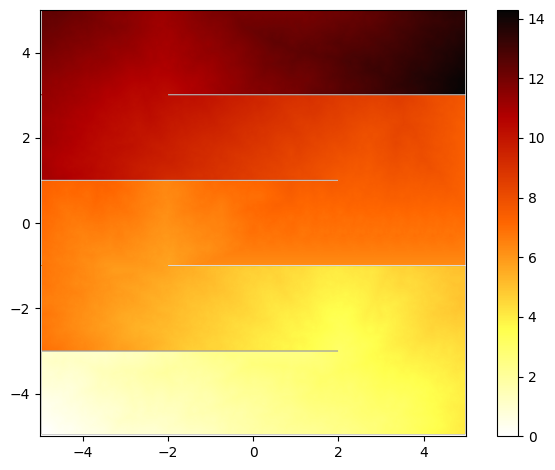

/tmp/ipykernel_1827/329287543.py:321: RuntimeWarning: invalid value encountered in subtract
  Tx[both_x] = (T_right[both_x] - T_left[both_x]) / (2 * dx)
/tmp/ipykernel_1827/329287543.py:322: RuntimeWarning: invalid value encountered in subtract
  Tx[only_right_x] = (T_right[only_right_x] - T_final[only_right_x]) / dx
/tmp/ipykernel_1827/329287543.py:323: RuntimeWarning: invalid value encountered in subtract
  Tx[only_left_x]  = (T_final[only_left_x] - T_left[only_left_x]) / dx
/tmp/ipykernel_1827/329287543.py:341: RuntimeWarning: invalid value encountered in subtract
  Ty[both_y] = (T_up[both_y] - T_down[both_y]) / (2 * dy)
/tmp/ipykernel_1827/329287543.py:342: RuntimeWarning: invalid value encountered in subtract
  Ty[only_up_y]   = (T_up[only_up_y] - T_final[only_up_y]) / dy
/tmp/ipykernel_1827/329287543.py:343: RuntimeWarning: invalid value encountered in subtract
  Ty[only_down_y] = (T_final[only_down_y] - T_down[only_down_y]) / dy
/tmp/ipykernel_1827/329287543.py:351: RuntimeWarni

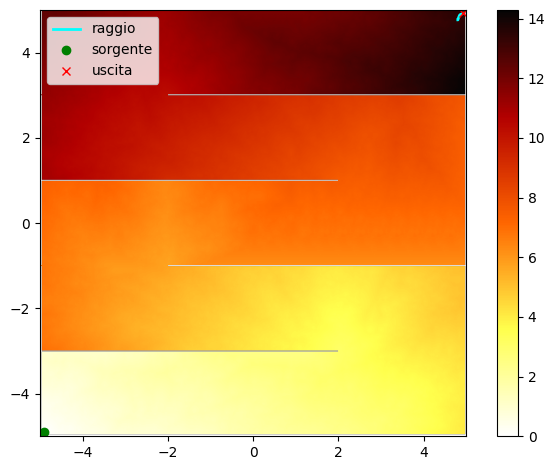

In [ ]:
# ==============================================================================
# -FIM CON GODUNOV ENO/WENO + RAGGI CON INTERP. BILINEARE SU LABIRINTO 500X500 -
# ==============================================================================

"""
In questa versione si è provato un metodo noto in letteratura come ENO/WENO
(Y.-T.  Zhang* and C.-W. Shu) per  ottenere un aggiornamento Godunov di ordine 2.
Dopodichè una volta calcolata la  T si è preceduto al tracciamento dei raggi con
discretizzazione del gradiente attraverso differenze finite + interpolazione
bilineare e rk4
"""

import numpy as np
import matplotlib.pyplot as plt

from typing import Text
from matplotlib import animation, rc
from IPython.display import HTML
from scipy.interpolate import RegularGridInterpolator
from matplotlib.colors import LinearSegmentedColormap
from google.colab import drive
from scipy.ndimage import distance_transform_edt

#discretizzazione del dominio

nx = 500
ny = 500
nRows = 500
nCols = 500
sidex = 5
sidey = 5
domain = [-sidex, sidex, -sidey, sidey]
x = np.linspace(domain[0], domain[1], nx)
y = np.linspace(domain[2], domain[3], ny)
dx = x[1] - x[0]
dy = y[1] - y[0]
[X, Y] = np.meshgrid(x, y)
eps = 1e-4

ix0 = 5
iy0 = 5

#ix0 = 2000
#iy0 = 2000

#campo di velocità e relativa sorgente in assenza di ostacoli
F = np.ones(X.shape)
F_oncart = RegularGridInterpolator((X[0, :], Y[:, 0]), F.T, method='linear', bounds_error=False, fill_value=None)

F = 1 * np.ones(X.shape)

# pareti del bordo
F[:, 1]   = np.inf   # parete sinistra
F[:, 498] = np.inf   # parete destra
F[1, :]   = np.inf   # parete sopra
F[498, :] = np.inf   # parete sotto

# primo muro orizzontale (riga 100, con apertura a sinistra)
F[99, :]       = np.inf
F[99, 349:498] = 1   # apertura: colonne 350-498 in MATLAB → 349:498 in Python

# secondo muro orizzontale (riga 200, con apertura a destra)
F[199, :]      = np.inf
F[199, 1:150]  = 1   # apertura: colonne 2-150 in MATLAB → 1:150 in Python

# terzo muro orizzontale (riga 300, con apertura a sinistra)
F[299, :]       = np.inf
F[299, 349:498] = 1

# quarto muro orizzontale (riga 400, con apertura a destra)
F[399, :]      = np.inf
F[399, 1:150]  = 1

wall_mask = np.isinf(F)

T = np.full(X.shape, np.inf)
T[iy0, ix0] = 0


active = np.zeros(T.shape, dtype=bool)

for dr, dc in [(0,-1),(0,1),(-1,0),(1,0)]:
    nr, nc = iy0 + dr, ix0 + dc
    if 0 <= nr < nRows and 0 <= nc < nCols:
        active[nr, nc] = True

T_old = np.full(T.shape, np.inf)
continua = True
h = dx

def minmod(a, b):
    """Limitatore minmod: stesso segno -> il piu' piccolo in modulo, altrimenti 0."""
    same_sign = (a * b) > 0
    result = np.where(np.abs(a) < np.abs(b), a, b)
    return np.where(same_sign, result, 0.0)


def _shift(T, wall_mask, r, c, nRows, nCols):
    """Legge T in (r,c) con clip sicuro; valido solo se dentro i bordi, non muro,
    e con valore finito (nodo gia' calcolato)."""
    rr = np.clip(r, 0, nRows - 1)
    cc = np.clip(c, 0, nCols - 1)
    in_bounds = (r >= 0) & (r < nRows) & (c >= 0) & (c < nCols)
    is_wall = wall_mask[rr, cc]
    raw_val = np.where(in_bounds, T[rr, cc], np.inf)
    is_finite = np.isfinite(raw_val)
    valid = in_bounds & ~is_wall & is_finite
    val = np.where(valid, raw_val, np.inf)
    return val, valid


def _axis_values_order1(T, wall_mask, row, col, axis, nRows, nCols):
    """Valori upwind ordine 1: i due vicini diretti (schema originale)."""
    if axis == 'x':
        f_m1, v_m1 = _shift(T, wall_mask, row, col - 1, nRows, nCols)
        f_p1, v_p1 = _shift(T, wall_mask, row, col + 1, nRows, nCols)
    else:
        f_m1, v_m1 = _shift(T, wall_mask, row - 1, col, nRows, nCols)
        f_p1, v_p1 = _shift(T, wall_mask, row + 1, col, nRows, nCols)
    return f_m1, f_p1, v_m1, v_p1


def _axis_values_eno2(T, wall_mask, row, col, axis, h, nRows, nCols):
    """
    Valori upwind ordine 2 (ENO2, Osher-Shu) lungo un asse.
    Le derivate D-/D+ sono ancorate al nodo i; la formula finale e' stata
    semplificata algebricamente per NON referenziare il valore del nodo
    corrente T[row,col] (che potrebbe essere ancora inf/non calcolato).
    """
    if axis == 'x':
        f_m2, v_m2 = _shift(T, wall_mask, row, col - 2, nRows, nCols)
        f_m1, v_m1 = _shift(T, wall_mask, row, col - 1, nRows, nCols)
        f_0,  v_0  = _shift(T, wall_mask, row, col,     nRows, nCols)
        f_p1, v_p1 = _shift(T, wall_mask, row, col + 1, nRows, nCols)
        f_p2, v_p2 = _shift(T, wall_mask, row, col + 2, nRows, nCols)
    else:
        f_m2, v_m2 = _shift(T, wall_mask, row - 2, col, nRows, nCols)
        f_m1, v_m1 = _shift(T, wall_mask, row - 1, col, nRows, nCols)
        f_0,  v_0  = _shift(T, wall_mask, row,     col, nRows, nCols)
        f_p1, v_p1 = _shift(T, wall_mask, row + 1, col, nRows, nCols)
        f_p2, v_p2 = _shift(T, wall_mask, row + 2, col, nRows, nCols)

    # derivate seconde discrete (curvatura); richiedono ANCHE che il nodo
    # centrale f_0 sia gia' finito, altrimenti la curvatura non ha senso
    D2_im1 = np.where(v_m2 & v_m1 & v_0, (f_0 - 2*f_m1 + f_m2) / h**2, 0.0)
    D2_i   = np.where(v_m1 & v_p1 & v_0, (f_p1 - 2*f_0 + f_m1) / h**2, 0.0)
    D2_ip1 = np.where(v_p1 & v_p2 & v_0, (f_p2 - 2*f_p1 + f_0) / h**2, 0.0)

    corr_minus = minmod(D2_im1, D2_i)
    corr_plus  = minmod(D2_i, D2_ip1)

    # formula semplificata algebricamente (f_0 si cancella, non compare piu'):
    #   val_minus = f_0 - h*D-_x u_i = f_m1 - (h^2/2)*corr_minus
    #   val_plus  = f_0 + h*D+_x u_i = f_p1 - (h^2/2)*corr_plus
    val_minus = np.where(v_m1, f_m1 - (h**2 / 2.0) * corr_minus, np.inf)
    val_plus  = np.where(v_p1, f_p1 - (h**2 / 2.0) * corr_plus,  np.inf)

    return val_minus, val_plus, v_m1, v_p1


def _solve_quadratic(Txmin, Tymin, f, h):
    """Quadratica di Godunov standard per l'eikonale, dati i due upwind per asse."""
    a = np.minimum(Txmin, Tymin)
    b = np.maximum(Txmin, Tymin)
    rhs = h / f

    cond = (b - a) < rhs
    disc = 2 * rhs**2 - (a - b)**2
    disc = np.maximum(disc, 0)

    u_quad = (a + b + np.sqrt(disc)) / 2
    u_lin = a + rhs

    u = np.where(cond, u_quad, u_lin)
    return u


def Godunov_update_order1(T, F, row, col):
    """
    Aggiornamento Godunov ORDINE 1 (schema originale upwind a un punto per asse).
    row, col: array di indici dei punti attivi.
    """
    nRows, nCols = T.shape
    f = F[row, col]

    x_m1, x_p1, vx_m1, vx_p1 = _axis_values_order1(T, wall_mask, row, col, 'x', nRows, nCols)
    y_m1, y_p1, vy_m1, vy_p1 = _axis_values_order1(T, wall_mask, row, col, 'y', nRows, nCols)

    Txmin = np.minimum(x_m1, x_p1)
    Tymin = np.minimum(y_m1, y_p1)

    return _solve_quadratic(Txmin, Tymin, f, h)


def Godunov_update(T, F, row, col):
    """
    Aggiornamento Godunov ORDINE 2 (ENO2, Osher-Shu 1991) per l'equazione eikonale 2D,
    con guardrail di causalita': se l'update ordine 2 viola la monotonia richiesta
    dal FIM (produce un valore inferiore al minimo upwind ordine-1, o non finito),
    ricade sull'update ordine 1 in quel punto per quell'iterazione.

    row, col: array di indici dei punti attivi.
    Usa le variabili globali wall_mask e h gia' definite nel resto dello script.
    """
    nRows, nCols = T.shape
    f = F[row, col]

    # --- ordine 1 (baseline: serve come fallback e come riferimento causale) ---
    x_m1, x_p1, vx_m1, vx_p1 = _axis_values_order1(T, wall_mask, row, col, 'x', nRows, nCols)
    y_m1, y_p1, vy_m1, vy_p1 = _axis_values_order1(T, wall_mask, row, col, 'y', nRows, nCols)

    Txmin_o1 = np.minimum(x_m1, x_p1)
    Tymin_o1 = np.minimum(y_m1, y_p1)
    q_order1 = _solve_quadratic(Txmin_o1, Tymin_o1, f, h)

    # --- ordine 2 (ENO2) ---
    x_minus, x_plus, vxm, vxp = _axis_values_eno2(T, wall_mask, row, col, 'x', h, nRows, nCols)
    y_minus, y_plus, vym, vyp = _axis_values_eno2(T, wall_mask, row, col, 'y', h, nRows, nCols)

    Txmin_o2 = np.minimum(x_minus, x_plus)
    Tymin_o2 = np.minimum(y_minus, y_plus)
    q_order2 = _solve_quadratic(Txmin_o2, Tymin_o2, f, h)

    # --- guardrail di causalita' ---
    min_neighbor = np.minimum(Txmin_o1, Tymin_o1)
    causal_ok = np.isfinite(q_order2) & (q_order2 >= min_neighbor - 1e-9)

    q = np.where(causal_ok, q_order2, q_order1)
    q = np.where(np.isfinite(q), q, np.inf)  # guard finale di sicurezza

    return q

def FIM(T, F, active, max_it = 5000):

    n_iter = 0
    while np.any(active) and n_iter < max_it:
        n_iter += 1
        row, col = np.where(active)
        p = T[row, col]
        q = Godunov_update(T, F, row, col)

        T[row, col] = q             # ← aggiorna T PRIMA del controllo convergenza

        converged_cond = np.abs(p - q) < eps
        conv_row, conv_col = row[converged_cond], col[converged_cond]

        active[conv_row, conv_col] = False

        for r, c in [(0, -1), (0, 1), (-1, 0), (1, 0)]:
            nb_row = conv_row + r
            nb_col = conv_col + c

            valid = (nb_row >= 0) & (nb_row < nRows) & (nb_col >= 0) & (nb_col < nCols)
            nb_row, nb_col = nb_row[valid], nb_col[valid]

            not_active = ~active[nb_row, nb_col]

            wall = np.isinf(F[nb_row, nb_col])

            nb_row = nb_row[~wall]
            nb_col = nb_col[~wall]

            if nb_row.size == 0:
                continue

            p2 = T[nb_row, nb_col]
            q2 = Godunov_update(T, F, nb_row, nb_col)

            improve = q2 < p2
            nb_row, nb_col, q2 = nb_row[improve], nb_col[improve], q2[improve]

            T[nb_row, nb_col] = q2
            active[nb_row, nb_col] = True

            if n_iter >= max_it:
              print(f"ATTENZIONE: FIM non converged ")
              break

    return T


T_final = FIM(T, F, active)

# Plot
fig, ax = plt.subplots()
im = ax.imshow(T_final, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal')
plt.colorbar(im, ax=ax)

stops = np.array([
    [1.00, 1.00, 1.00],
    [1.00, 1.00, 0.30],
    [1.00, 0.40, 0.00],
    [0.70, 0.00, 0.00],
    [0.02, 0.02, 0.02],
])
cmap2 = LinearSegmentedColormap.from_list("custom", stops, N=256)
im.set_cmap(cmap2)

plt.tight_layout()
plt.show()


# ----------------------------------RAGGI---------------------------------------
## VERSIONE RK4 con interpolazione bilineare##

def Gradient_FD(T_final, F, dx, dy):
    wall_mask = np.isinf(F)
    nRows, nCols = T_final.shape

    Tx = np.zeros_like(T_final)
    Ty = np.zeros_like(T_final)

    # --- Derivata rispetto a x (colonne) ---
    valid = ~wall_mask

    left_ok  = np.zeros_like(valid)
    right_ok = np.zeros_like(valid)
    left_ok[:, 1:]  = valid[:, :-1]   # vicino a sinistra è valido
    right_ok[:, :-1] = valid[:, 1:]   # vicino a destra è valido

    T_left  = np.full_like(T_final, np.nan)
    T_right = np.full_like(T_final, np.nan)
    T_left[:, 1:]  = T_final[:, :-1]
    T_right[:, :-1] = T_final[:, 1:]

    both_x = left_ok & right_ok
    only_left_x  = left_ok & ~right_ok    # solo sinistra disponibile → backward diff
    only_right_x = right_ok & ~left_ok    # solo destra disponibile → forward diff

    Tx[both_x] = (T_right[both_x] - T_left[both_x]) / (2 * dx)
    Tx[only_right_x] = (T_right[only_right_x] - T_final[only_right_x]) / dx
    Tx[only_left_x]  = (T_final[only_left_x] - T_left[only_left_x]) / dx
    # entrambi i vicini muro (o cella stessa muro) → Tx resta 0

    # --- Derivata rispetto a y (righe) ---
    down_ok = np.zeros_like(valid)
    up_ok   = np.zeros_like(valid)
    down_ok[1:, :] = valid[:-1, :]    # vicino sotto è valido
    up_ok[:-1, :]  = valid[1:, :]     # vicino sopra è valido

    T_down = np.full_like(T_final, np.nan)
    T_up   = np.full_like(T_final, np.nan)
    T_down[1:, :] = T_final[:-1, :]
    T_up[:-1, :]  = T_final[1:, :]

    both_y = down_ok & up_ok
    only_down_y = down_ok & ~up_ok
    only_up_y   = up_ok & ~down_ok

    Ty[both_y] = (T_up[both_y] - T_down[both_y]) / (2 * dy)
    Ty[only_up_y]   = (T_up[only_up_y] - T_final[only_up_y]) / dy
    Ty[only_down_y] = (T_final[only_down_y] - T_down[only_down_y]) / dy

    # --- Rinormalizzazione secondo l'eikonale: |grad T| = 1/F ---
    grad_norm = np.sqrt(Tx**2 + Ty**2)
    scale = np.zeros_like(grad_norm)
    finite_F = np.isfinite(F) & (grad_norm > 1e-12)
    scale[finite_F] = 1.0 / (F[finite_F] * grad_norm[finite_F])

    Tx = np.where(finite_F, Tx * scale, 0.0)
    Ty = np.where(finite_F, Ty * scale, 0.0)

    # azzera esplicitamente le celle muro
    Tx[wall_mask] = 0.0
    Ty[wall_mask] = 0.0

    return Tx, Ty

Tx = np.zeros_like(T_final)
Ty = np.zeros_like(T_final)

Tx, Ty = Gradient_FD(T_final, F, dx, dy)


def fill_wall_nans(field, wall_mask):
    """Sostituisce i valori nelle celle muro con quelli della cella valida più vicina."""
    # indici della cella valida più vicina per ogni punto della griglia
    idx = distance_transform_edt(wall_mask, return_distances=False, return_indices=True)
    return field[tuple(idx)]


wall_mask = np.isinf(F)

Tx_filled = fill_wall_nans(Tx, wall_mask)
Ty_filled = fill_wall_nans(Ty, wall_mask)

Tx_interp = RegularGridInterpolator((y, x), Tx_filled, method='linear',
                                     bounds_error=False, fill_value=None)
Ty_interp = RegularGridInterpolator((y, x), Ty_filled, method='linear',
                                     bounds_error=False, fill_value=None)



def grad_at(pt, Tx_interp, Ty_interp):
    """pt = (px, py) in coordinate cartesiane."""
    px, py = pt
    point = np.array([[py, px]])  # RegularGridInterpolator vuole shape (n_points, n_dims)
    gx = Tx_interp(point)[0]
    gy = Ty_interp(point)[0]
    if not (np.isfinite(gx) and np.isfinite(gy)):
        return np.array([0.0, 0.0])
    return np.array([gx, gy])


def trace_ray_rk4(start_pt, Tx_interp, Ty_interp, source_pt, ds, max_steps):
    """
    Integra all'indietro seguendo -grad(T) a partire da start_pt (uscita)
    fino ad avvicinarsi a source_pt (sorgente).
    """
    pt = np.array(start_pt, dtype=float)
    ray = [pt.copy()]

    for step in range(max_steps):

        if step > 1 and np.linalg.norm(ray[-1] - ray[-2]) < 1e-8:
          break

        k1 = -grad_at(pt, Tx_interp, Ty_interp)
        if np.linalg.norm(k1) < 1e-12:
            break
        k2 = -grad_at(pt + 0.5*ds*k1, Tx_interp, Ty_interp)
        k3 = -grad_at(pt + 0.5*ds*k2, Tx_interp, Ty_interp)
        k4 = -grad_at(pt + ds*k3, Tx_interp, Ty_interp)

        dpt = (k1 + 2*k2 + 2*k3 + k4) / 6.0
        pt_new = pt + ds * dpt

        ray.append(pt_new.copy())

        # criterio di arresto: raggio arrivato vicino alla sorgente
        if np.linalg.norm(pt_new - np.array(source_pt)) < ds:
            ray.append(np.array(source_pt, dtype=float))
            break

        # criterio di stagnazione (raggio bloccato, es. contro un muro)
        if step > 1 and np.linalg.norm(ray[-1] - ray[-2]) < 1e-8:
            break

        pt = pt_new

    return np.array(ray)


# coordinate cartesiane del punto sorgente
source_pt = (x[ix0], y[iy0])

# punto d'uscita in alto a destra del dominio
exit_pt = (x[495], y[495])

ds = dx  # passo di integrazione
max_steps = 5000

ray = trace_ray_rk4(exit_pt, Tx_interp, Ty_interp, source_pt, ds, max_steps)



fig, ax = plt.subplots()
im = ax.imshow(T_final, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal', cmap=cmap2)
plt.colorbar(im, ax=ax)

ax.plot(ray[:, 0], ray[:, 1], color='cyan', linewidth=2, label='raggio')
ax.plot(*source_pt, 'go', label='sorgente')
ax.plot(*exit_pt, 'rx', label='uscita')
ax.legend()
plt.tight_layout()
plt.show()

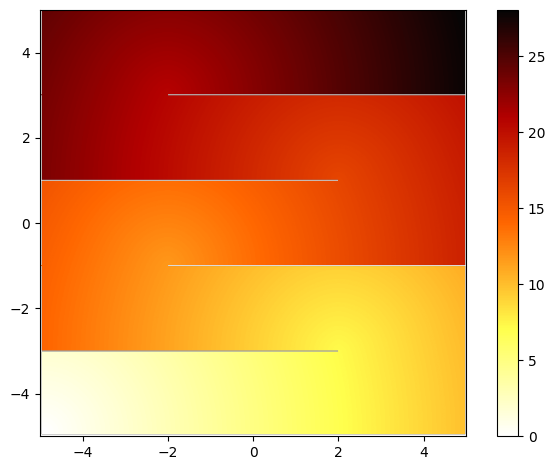

/tmp/ipykernel_741/2104881168.py:302: RuntimeWarning: invalid value encountered in subtract
  Tx[both_x] = (T_right[both_x] - T_left[both_x]) / (2 * dx)
/tmp/ipykernel_741/2104881168.py:303: RuntimeWarning: invalid value encountered in subtract
  Tx[only_right_x] = (T_right[only_right_x] - T_final[only_right_x]) / dx
/tmp/ipykernel_741/2104881168.py:304: RuntimeWarning: invalid value encountered in subtract
  Tx[only_left_x]  = (T_final[only_left_x] - T_left[only_left_x]) / dx
/tmp/ipykernel_741/2104881168.py:322: RuntimeWarning: invalid value encountered in subtract
  Ty[both_y] = (T_up[both_y] - T_down[both_y]) / (2 * dy)
/tmp/ipykernel_741/2104881168.py:323: RuntimeWarning: invalid value encountered in subtract
  Ty[only_up_y]   = (T_up[only_up_y] - T_final[only_up_y]) / dy
/tmp/ipykernel_741/2104881168.py:324: RuntimeWarning: invalid value encountered in subtract
  Ty[only_down_y] = (T_final[only_down_y] - T_down[only_down_y]) / dy
/tmp/ipykernel_741/2104881168.py:332: RuntimeWarni

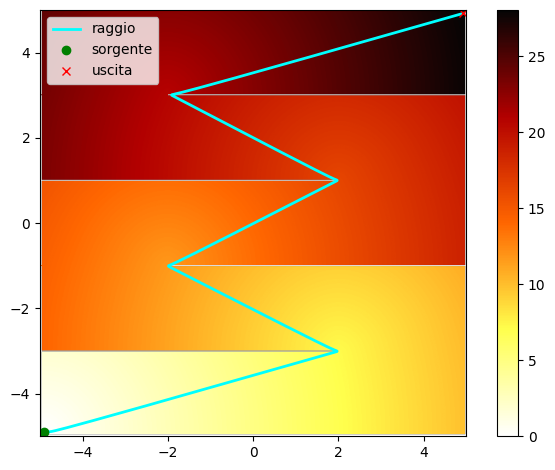

In [ ]:
# ==============================================================================
# FIM CON GODUNOV 1 CORRETTO + RAGGI CON INTERP. BILINEARE SU LABIRINTO 500X500
# ==============================================================================

"""
In questa versione si è provato un metodo presente in letteratura come "A compact
upwind second order scheme for the Eikonal equation" di Jean-David Benamou,
Songting Luo, Hongkai Zhao in cui si prova ad ottenere un aggiornamento Godunov
di ordine 2 applicando una correzione all'aggiornamento classico di ordine 1.
Dopodichè una volta calcolata la T si è preceduto al tracciamento dei raggi con
discretizzazione del gradiente attraverso differenze finite + interpolazione
bilineare e rk4.
"""

import numpy as np
import matplotlib.pyplot as plt

from typing import Text
from matplotlib import animation, rc
from IPython.display import HTML
from scipy.interpolate import RegularGridInterpolator
from matplotlib.colors import LinearSegmentedColormap
from google.colab import drive
from scipy.ndimage import distance_transform_edt

#discretizzazione del dominio

nx = 500
ny = 500
nRows = 500
nCols = 500
sidex = 5
sidey = 5
domain = [-sidex, sidex, -sidey, sidey]
x = np.linspace(domain[0], domain[1], nx)
y = np.linspace(domain[2], domain[3], ny)
dx = x[1] - x[0]
dy = y[1] - y[0]
[X, Y] = np.meshgrid(x, y)
eps = 1e-6

ix0 = 5
iy0 = 5

#ix0 = 2000
#iy0 = 2000

#campo di velocità e relativa sorgente in assenza di ostacoli
F = np.ones(X.shape)
F_oncart = RegularGridInterpolator((X[0, :], Y[:, 0]), F.T, method='linear', bounds_error=False, fill_value=None)

F = 1 * np.ones(X.shape)

# pareti del bordo
F[:, 1]   = np.inf   # parete sinistra
F[:, 498] = np.inf   # parete destra
F[1, :]   = np.inf   # parete sopra
F[498, :] = np.inf   # parete sotto

# primo muro orizzontale (riga 100, con apertura a sinistra)
F[99, :]       = np.inf
F[99, 349:498] = 1   # apertura: colonne 350-498 in MATLAB → 349:498 in Python

# secondo muro orizzontale (riga 200, con apertura a destra)
F[199, :]      = np.inf
F[199, 1:150]  = 1   # apertura: colonne 2-150 in MATLAB → 1:150 in Python

# terzo muro orizzontale (riga 300, con apertura a sinistra)
F[299, :]       = np.inf
F[299, 349:498] = 1

# quarto muro orizzontale (riga 400, con apertura a destra)
F[399, :]      = np.inf
F[399, 1:150]  = 1

T = np.full(X.shape, np.inf)
T[iy0, ix0] = 0


active = np.zeros(T.shape, dtype=bool)

for dr, dc in [(0,-1),(0,1),(-1,0),(1,0)]:
    nr, nc = iy0 + dr, ix0 + dc
    if 0 <= nr < nRows and 0 <= nc < nCols:
        active[nr, nc] = True

T_old = np.full(T.shape, np.inf)
continua = True
h = dx

def Godunov_update(T, F, row, col):
  left  = np.where(col - 1 >= 0,      T[row, np.clip(col - 1, 0, nCols - 1)], np.inf)
  right = np.where(col + 1 < nCols,   T[row, np.clip(col + 1, 0, nCols - 1)], np.inf)
  down  = np.where(row - 1 >= 0,      T[np.clip(row - 1, 0, nRows - 1), col], np.inf)
  up    = np.where(row + 1 < nRows,   T[np.clip(row + 1, 0, nRows - 1), col], np.inf)

  Txmin = np.minimum(left, right)
  Tymin = np.minimum(down,up)

  a = np.minimum(Txmin, Tymin)
  b = np.maximum(Txmin, Tymin)

  f = F[row,col]
  rhs = h / f

  cond = (b - a) < rhs
  disc = 2 * rhs**2 - (a - b)**2
  disc = np.maximum(disc, 0)

  u_quad = (a + b + np.sqrt(disc)) / 2
  u_lin = a + rhs

  u = np.where(cond, u_quad, u_lin)

  return u


def FIM(T, F, active):

    while np.any(active):

        row, col = np.where(active)
        p = T[row, col]
        q = Godunov_update(T, F, row, col)

        T[row, col] = q             # ← aggiorna T PRIMA del controllo convergenza

        converged_cond = np.abs(p - q) < eps
        conv_row, conv_col = row[converged_cond], col[converged_cond]

        active[conv_row, conv_col] = False

        for r, c in [(0, -1), (0, 1), (-1, 0), (1, 0)]:
            nb_row = conv_row + r
            nb_col = conv_col + c

            valid = (nb_row >= 0) & (nb_row < nRows) & (nb_col >= 0) & (nb_col < nCols)
            nb_row, nb_col = nb_row[valid], nb_col[valid]

            not_active = ~active[nb_row, nb_col]

            wall = np.isinf(F[nb_row, nb_col])

            nb_row = nb_row[~wall]
            nb_col = nb_col[~wall]

            if nb_row.size == 0:
                continue

            p2 = T[nb_row, nb_col]
            q2 = Godunov_update(T, F, nb_row, nb_col)

            improve = q2 < p2
            nb_row, nb_col, q2 = nb_row[improve], nb_col[improve], q2[improve]

            T[nb_row, nb_col] = q2
            active[nb_row, nb_col] = True

    return T


T_final_order1 = FIM(T, F, active)

def compute_upwind_gradient_order1(T_final, wall_mask, h, nRows, nCols):
    """
    Calcola il gradiente upwind ordine 1 (a1, b1) in ogni punto, usando
    differenze upwind semplici (il "gradiente superconvergente" del paper).
    """
    a1 = np.zeros_like(T_final)
    b1 = np.zeros_like(T_final)

    valid = ~wall_mask & np.isfinite(T_final)

    left_ok  = np.zeros_like(valid); left_ok[:, 1:]  = valid[:, :-1]
    right_ok = np.zeros_like(valid); right_ok[:, :-1] = valid[:, 1:]

    T_left  = np.full_like(T_final, np.inf); T_left[:, 1:]  = T_final[:, :-1]
    T_right = np.full_like(T_final, np.inf); T_right[:, :-1] = T_final[:, 1:]

    use_left_x  = left_ok & (~right_ok | (T_left <= T_right))
    use_right_x = right_ok & ~use_left_x

    a1[use_left_x]  = (T_final[use_left_x] - T_left[use_left_x])  / h
    a1[use_right_x] = (T_right[use_right_x] - T_final[use_right_x]) / h

    down_ok = np.zeros_like(valid); down_ok[1:, :] = valid[:-1, :]
    up_ok   = np.zeros_like(valid); up_ok[:-1, :]  = valid[1:, :]

    T_down = np.full_like(T_final, np.inf); T_down[1:, :] = T_final[:-1, :]
    T_up   = np.full_like(T_final, np.inf); T_up[:-1, :]  = T_final[1:, :]

    use_down_y = down_ok & (~up_ok | (T_down <= T_up))
    use_up_y   = up_ok & ~use_down_y

    b1[use_down_y] = (T_final[use_down_y] - T_down[use_down_y]) / h
    b1[use_up_y]   = (T_up[use_up_y] - T_final[use_up_y]) / h

    return a1, b1


def second_order_correction(T_final, F, wall_mask, h, min_grad=1e-8):
    """
    Correzione one-pass ordine 2 (Benamou, Luo, Zhao 2010), versione BASE.
    """
    nRows, nCols = T_final.shape
    a1_field, b1_field = compute_upwind_gradient_order1(T_final, wall_mask, h, nRows, nCols)

    T_corrected = T_final.copy()

    valid_mask = ~wall_mask & np.isfinite(T_final) & (T_final > 0)
    rows, cols = np.where(valid_mask)
    order = np.argsort(T_final[rows, cols])
    rows, cols = rows[order], cols[order]

    for r, c in zip(rows, cols):
        a1 = a1_field[r, c]
        b1 = b1_field[r, c]

        if abs(a1) < min_grad or abs(b1) < min_grad:
            continue

        n_local = 1.0 / F[r, c]
        if not np.isfinite(n_local):
            continue

        sr = -1 if b1 > 0 else 1
        sc = -1 if a1 > 0 else 1

        r_m, c_m = r + sr, c
        r_c, c_c = r, c + sc
        r_d, c_d = r + sr, c + sc

        def ok(rr, cc):
            return (0 <= rr < nRows and 0 <= cc < nCols
                    and not wall_mask[rr, cc]
                    and np.isfinite(T_final[rr, cc]))

        if not (ok(r_m, c_m) and ok(r_c, c_c) and ok(r_d, c_d)):
            continue

        phi_0h  = T_final[r_m, c_m]
        phi_h0  = T_final[r_c, c_c]
        phi_hh  = T_final[r_d, c_d]

        a1_abs, b1_abs = abs(a1), abs(b1)

        A = (b1_abs / (2*a1_abs)) * (phi_0h - phi_hh) - (1 - b1_abs/(2*a1_abs)) * phi_h0
        B = (a1_abs / (2*b1_abs)) * (phi_h0 - phi_hh) - (1 - a1_abs/(2*b1_abs)) * phi_0h

        c1 = (1 - b1_abs/(2*a1_abs))**2 + (1 - a1_abs/(2*b1_abs))**2
        c2 = 2*(1 - b1_abs/(2*a1_abs))*A + 2*(1 - a1_abs/(2*b1_abs))*B
        c3 = A**2 + B**2 - h**2 * n_local**2

        disc = c2**2 - 4*c1*c3
        if disc < 0 or c1 <= 0:
            continue

        phi_00 = (-c2 + np.sqrt(disc)) / (2*c1)

        if np.isfinite(phi_00) and abs(phi_00 - T_final[r, c]) < 10 * h:
            T_corrected[r, c] = phi_00

    return T_corrected

T_final = second_order_correction(T_final_order1, F, wall_mask, h)

T_order2 = T_final.copy()
fig, ax = plt.subplots()
im = ax.imshow(T_final, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal')
plt.colorbar(im, ax=ax)

stops = np.array([
    [1.00, 1.00, 1.00],
    [1.00, 1.00, 0.30],
    [1.00, 0.40, 0.00],
    [0.70, 0.00, 0.00],
    [0.02, 0.02, 0.02],
])
cmap2 = LinearSegmentedColormap.from_list("custom", stops, N=256)
im.set_cmap(cmap2)

plt.tight_layout()
plt.show()


# ----------------------------------RAGGI---------------------------------------


def Gradient_FD(T_final, F, dx, dy):
    wall_mask = np.isinf(F)
    nRows, nCols = T_final.shape

    Tx = np.zeros_like(T_final)
    Ty = np.zeros_like(T_final)

    # --- Derivata rispetto a x (colonne) ---
    valid = ~wall_mask

    left_ok  = np.zeros_like(valid)
    right_ok = np.zeros_like(valid)
    left_ok[:, 1:]  = valid[:, :-1]   # vicino a sinistra è valido
    right_ok[:, :-1] = valid[:, 1:]   # vicino a destra è valido

    T_left  = np.full_like(T_final, np.nan)
    T_right = np.full_like(T_final, np.nan)
    T_left[:, 1:]  = T_final[:, :-1]
    T_right[:, :-1] = T_final[:, 1:]

    both_x = left_ok & right_ok
    only_left_x  = left_ok & ~right_ok    # solo sinistra disponibile → backward diff
    only_right_x = right_ok & ~left_ok    # solo destra disponibile → forward diff

    Tx[both_x] = (T_right[both_x] - T_left[both_x]) / (2 * dx)
    Tx[only_right_x] = (T_right[only_right_x] - T_final[only_right_x]) / dx
    Tx[only_left_x]  = (T_final[only_left_x] - T_left[only_left_x]) / dx
    # entrambi i vicini muro (o cella stessa muro) → Tx resta 0

    # --- Derivata rispetto a y (righe) ---
    down_ok = np.zeros_like(valid)
    up_ok   = np.zeros_like(valid)
    down_ok[1:, :] = valid[:-1, :]    # vicino sotto è valido
    up_ok[:-1, :]  = valid[1:, :]     # vicino sopra è valido

    T_down = np.full_like(T_final, np.nan)
    T_up   = np.full_like(T_final, np.nan)
    T_down[1:, :] = T_final[:-1, :]
    T_up[:-1, :]  = T_final[1:, :]

    both_y = down_ok & up_ok
    only_down_y = down_ok & ~up_ok
    only_up_y   = up_ok & ~down_ok

    Ty[both_y] = (T_up[both_y] - T_down[both_y]) / (2 * dy)
    Ty[only_up_y]   = (T_up[only_up_y] - T_final[only_up_y]) / dy
    Ty[only_down_y] = (T_final[only_down_y] - T_down[only_down_y]) / dy

    # --- Rinormalizzazione secondo l'eikonale: |grad T| = 1/F ---
    grad_norm = np.sqrt(Tx**2 + Ty**2)
    scale = np.zeros_like(grad_norm)
    finite_F = np.isfinite(F) & (grad_norm > 1e-12)
    scale[finite_F] = 1.0 / (F[finite_F] * grad_norm[finite_F])

    Tx = np.where(finite_F, Tx * scale, 0.0)
    Ty = np.where(finite_F, Ty * scale, 0.0)

    # azzera esplicitamente le celle muro
    Tx[wall_mask] = 0.0
    Ty[wall_mask] = 0.0

    return Tx, Ty

Tx = np.zeros_like(T_final)
Ty = np.zeros_like(T_final)

Tx, Ty = Gradient_FD(T_final, F, dx, dy)


def fill_wall_nans(field, wall_mask):
    """Sostituisce i valori nelle celle muro con quelli della cella valida più vicina."""
    # indici della cella valida più vicina per ogni punto della griglia
    idx = distance_transform_edt(wall_mask, return_distances=False, return_indices=True)
    return field[tuple(idx)]


wall_mask = np.isinf(F)

Tx_filled = fill_wall_nans(Tx, wall_mask)
Ty_filled = fill_wall_nans(Ty, wall_mask)

Tx_interp = RegularGridInterpolator((y, x), Tx_filled, method='linear',
                                     bounds_error=False, fill_value=None)
Ty_interp = RegularGridInterpolator((y, x), Ty_filled, method='linear',
                                     bounds_error=False, fill_value=None)



def grad_at(pt, Tx_interp, Ty_interp):
    """pt = (px, py) in coordinate cartesiane."""
    px, py = pt
    point = np.array([[py, px]])  # RegularGridInterpolator vuole shape (n_points, n_dims)
    gx = Tx_interp(point)[0]
    gy = Ty_interp(point)[0]
    if not (np.isfinite(gx) and np.isfinite(gy)):
        return np.array([0.0, 0.0])
    return np.array([gx, gy])


def trace_ray_rk4(start_pt, Tx_interp, Ty_interp, source_pt, ds, max_steps):
    """
    Integra all'indietro seguendo -grad(T) a partire da start_pt (uscita)
    fino ad avvicinarsi a source_pt (sorgente).
    """
    pt = np.array(start_pt, dtype=float)
    ray = [pt.copy()]

    for step in range(max_steps):

        if step > 1 and np.linalg.norm(ray[-1] - ray[-2]) < 1e-8:
          break

        k1 = -grad_at(pt, Tx_interp, Ty_interp)
        if np.linalg.norm(k1) < 1e-12:
            break
        k2 = -grad_at(pt + 0.5*ds*k1, Tx_interp, Ty_interp)
        k3 = -grad_at(pt + 0.5*ds*k2, Tx_interp, Ty_interp)
        k4 = -grad_at(pt + ds*k3, Tx_interp, Ty_interp)

        dpt = (k1 + 2*k2 + 2*k3 + k4) / 6.0
        pt_new = pt + ds * dpt

        ray.append(pt_new.copy())

        # criterio di arresto: raggio arrivato vicino alla sorgente
        if np.linalg.norm(pt_new - np.array(source_pt)) < ds:
            ray.append(np.array(source_pt, dtype=float))
            break

        # criterio di stagnazione (raggio bloccato, es. contro un muro)
        if step > 1 and np.linalg.norm(ray[-1] - ray[-2]) < 1e-8:
            break

        pt = pt_new

    return np.array(ray)


# coordinate cartesiane del punto sorgente
source_pt = (x[ix0], y[iy0])

# punto d'uscita in alto a destra del dominio
exit_pt = (x[495], y[495])

ds = dx  # passo di integrazione
max_steps = 5000

ray = trace_ray_rk4(exit_pt, Tx_interp, Ty_interp, source_pt, ds, max_steps)



fig, ax = plt.subplots()
im = ax.imshow(T_final, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal', cmap=cmap2)
plt.colorbar(im, ax=ax)

ax.plot(ray[:, 0], ray[:, 1], color='cyan', linewidth=2, label='raggio')
ax.plot(*source_pt, 'go', label='sorgente')
ax.plot(*exit_pt, 'rx', label='uscita')
ax.legend()
plt.tight_layout()
plt.show()

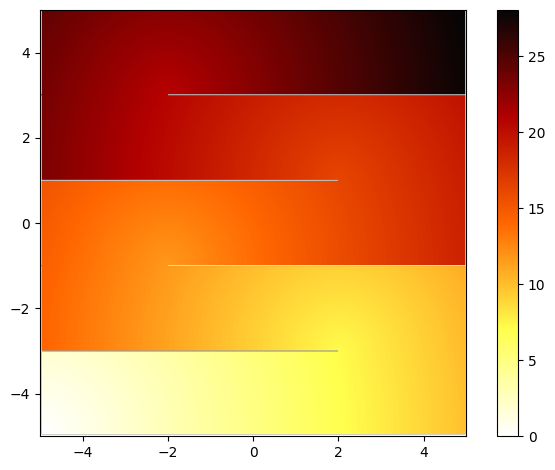

/tmp/ipykernel_741/2433802666.py:200: RuntimeWarning: invalid value encountered in subtract
  Tx[both_x] = (T_right[both_x] - T_left[both_x]) / (2 * dx)
/tmp/ipykernel_741/2433802666.py:201: RuntimeWarning: invalid value encountered in subtract
  Tx[only_right_x] = (T_right[only_right_x] - T_final[only_right_x]) / dx
/tmp/ipykernel_741/2433802666.py:202: RuntimeWarning: invalid value encountered in subtract
  Tx[only_left_x]  = (T_final[only_left_x] - T_left[only_left_x]) / dx
/tmp/ipykernel_741/2433802666.py:220: RuntimeWarning: invalid value encountered in subtract
  Ty[both_y] = (T_up[both_y] - T_down[both_y]) / (2 * dy)
/tmp/ipykernel_741/2433802666.py:221: RuntimeWarning: invalid value encountered in subtract
  Ty[only_up_y]   = (T_up[only_up_y] - T_final[only_up_y]) / dy
/tmp/ipykernel_741/2433802666.py:222: RuntimeWarning: invalid value encountered in subtract
  Ty[only_down_y] = (T_final[only_down_y] - T_down[only_down_y]) / dy
/tmp/ipykernel_741/2433802666.py:230: RuntimeWarni

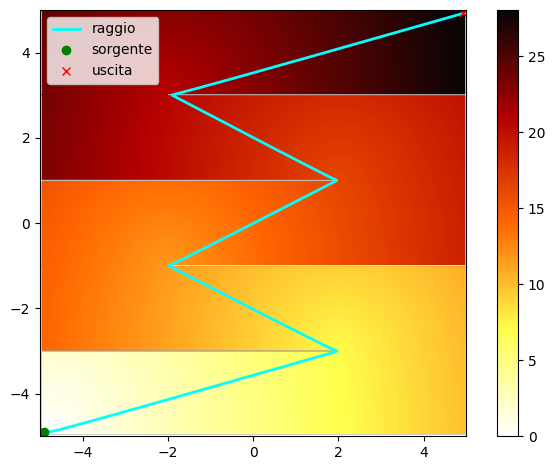

In [ ]:
## VERSIONE FIM con raggio##

import numpy as np
import matplotlib.pyplot as plt

from typing import Text
from matplotlib import animation, rc
from IPython.display import HTML
from scipy.interpolate import RegularGridInterpolator
from matplotlib.colors import LinearSegmentedColormap
from google.colab import drive
from scipy.ndimage import distance_transform_edt

#discretizzazione del dominio

nx = 500
ny = 500
nRows = 500
nCols = 500
sidex = 5
sidey = 5
domain = [-sidex, sidex, -sidey, sidey]
x = np.linspace(domain[0], domain[1], nx)
y = np.linspace(domain[2], domain[3], ny)
dx = x[1] - x[0]
dy = y[1] - y[0]
[X, Y] = np.meshgrid(x, y)
eps = 1e-6

ix0 = 5
iy0 = 5

#ix0 = 2000
#iy0 = 2000

#campo di velocità e relativa sorgente in assenza di ostacoli
F = np.ones(X.shape)
F_oncart = RegularGridInterpolator((X[0, :], Y[:, 0]), F.T, method='linear', bounds_error=False, fill_value=None)

F = 1 * np.ones(X.shape)

# pareti del bordo
F[:, 1]   = np.inf   # parete sinistra
F[:, 498] = np.inf   # parete destra
F[1, :]   = np.inf   # parete sopra
F[498, :] = np.inf   # parete sotto

# primo muro orizzontale (riga 100, con apertura a sinistra)
F[99, :]       = np.inf
F[99, 349:498] = 1   # apertura: colonne 350-498 in MATLAB → 349:498 in Python

# secondo muro orizzontale (riga 200, con apertura a destra)
F[199, :]      = np.inf
F[199, 1:150]  = 1   # apertura: colonne 2-150 in MATLAB → 1:150 in Python

# terzo muro orizzontale (riga 300, con apertura a sinistra)
F[299, :]       = np.inf
F[299, 349:498] = 1

# quarto muro orizzontale (riga 400, con apertura a destra)
F[399, :]      = np.inf
F[399, 1:150]  = 1

T = np.full(X.shape, np.inf)
T[iy0, ix0] = 0


active = np.zeros(T.shape, dtype=bool)

for dr, dc in [(0,-1),(0,1),(-1,0),(1,0)]:
    nr, nc = iy0 + dr, ix0 + dc
    if 0 <= nr < nRows and 0 <= nc < nCols:
        active[nr, nc] = True

T_old = np.full(T.shape, np.inf)
continua = True
h = dx

def Godunov_update(T, F, row, col):
  left  = np.where(col - 1 >= 0,      T[row, np.clip(col - 1, 0, nCols - 1)], np.inf)
  right = np.where(col + 1 < nCols,   T[row, np.clip(col + 1, 0, nCols - 1)], np.inf)
  down  = np.where(row - 1 >= 0,      T[np.clip(row - 1, 0, nRows - 1), col], np.inf)
  up    = np.where(row + 1 < nRows,   T[np.clip(row + 1, 0, nRows - 1), col], np.inf)

  Txmin = np.minimum(left, right)
  Tymin = np.minimum(down,up)

  a = np.minimum(Txmin, Tymin)
  b = np.maximum(Txmin, Tymin)

  f = F[row,col]
  rhs = h / f

  cond = (b - a) < rhs
  disc = 2 * rhs**2 - (a - b)**2
  disc = np.maximum(disc, 0)

  u_quad = (a + b + np.sqrt(disc)) / 2
  u_lin = a + rhs

  u = np.where(cond, u_quad, u_lin)

  return u


def FIM(T, F, active):

    while np.any(active):

        row, col = np.where(active)
        p = T[row, col]
        q = Godunov_update(T, F, row, col)

        T[row, col] = q             # ← aggiorna T PRIMA del controllo convergenza

        converged_cond = np.abs(p - q) < eps
        conv_row, conv_col = row[converged_cond], col[converged_cond]

        active[conv_row, conv_col] = False

        for r, c in [(0, -1), (0, 1), (-1, 0), (1, 0)]:
            nb_row = conv_row + r
            nb_col = conv_col + c

            valid = (nb_row >= 0) & (nb_row < nRows) & (nb_col >= 0) & (nb_col < nCols)
            nb_row, nb_col = nb_row[valid], nb_col[valid]

            not_active = ~active[nb_row, nb_col]

            wall = np.isinf(F[nb_row, nb_col])

            nb_row = nb_row[~wall]
            nb_col = nb_col[~wall]

            if nb_row.size == 0:
                continue

            p2 = T[nb_row, nb_col]
            q2 = Godunov_update(T, F, nb_row, nb_col)

            improve = q2 < p2
            nb_row, nb_col, q2 = nb_row[improve], nb_col[improve], q2[improve]

            T[nb_row, nb_col] = q2
            active[nb_row, nb_col] = True

    return T


T_final = FIM(T, F, active)

T_order1 = T_final.copy()
# Plot
fig, ax = plt.subplots()
im = ax.imshow(T_final, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal')
plt.colorbar(im, ax=ax)

stops = np.array([
    [1.00, 1.00, 1.00],
    [1.00, 1.00, 0.30],
    [1.00, 0.40, 0.00],
    [0.70, 0.00, 0.00],
    [0.02, 0.02, 0.02],
])
cmap2 = LinearSegmentedColormap.from_list("custom", stops, N=256)
im.set_cmap(cmap2)

plt.tight_layout()
plt.show()


# ----------------------------------RAGGI---------------------------------------


def Gradient_FD(T_final, F, dx, dy):
    wall_mask = np.isinf(F)
    nRows, nCols = T_final.shape

    Tx = np.zeros_like(T_final)
    Ty = np.zeros_like(T_final)

    # --- Derivata rispetto a x (colonne) ---
    valid = ~wall_mask

    left_ok  = np.zeros_like(valid)
    right_ok = np.zeros_like(valid)
    left_ok[:, 1:]  = valid[:, :-1]   # vicino a sinistra è valido
    right_ok[:, :-1] = valid[:, 1:]   # vicino a destra è valido

    T_left  = np.full_like(T_final, np.nan)
    T_right = np.full_like(T_final, np.nan)
    T_left[:, 1:]  = T_final[:, :-1]
    T_right[:, :-1] = T_final[:, 1:]

    both_x = left_ok & right_ok
    only_left_x  = left_ok & ~right_ok    # solo sinistra disponibile → backward diff
    only_right_x = right_ok & ~left_ok    # solo destra disponibile → forward diff

    Tx[both_x] = (T_right[both_x] - T_left[both_x]) / (2 * dx)
    Tx[only_right_x] = (T_right[only_right_x] - T_final[only_right_x]) / dx
    Tx[only_left_x]  = (T_final[only_left_x] - T_left[only_left_x]) / dx
    # entrambi i vicini muro (o cella stessa muro) → Tx resta 0

    # --- Derivata rispetto a y (righe) ---
    down_ok = np.zeros_like(valid)
    up_ok   = np.zeros_like(valid)
    down_ok[1:, :] = valid[:-1, :]    # vicino sotto è valido
    up_ok[:-1, :]  = valid[1:, :]     # vicino sopra è valido

    T_down = np.full_like(T_final, np.nan)
    T_up   = np.full_like(T_final, np.nan)
    T_down[1:, :] = T_final[:-1, :]
    T_up[:-1, :]  = T_final[1:, :]

    both_y = down_ok & up_ok
    only_down_y = down_ok & ~up_ok
    only_up_y   = up_ok & ~down_ok

    Ty[both_y] = (T_up[both_y] - T_down[both_y]) / (2 * dy)
    Ty[only_up_y]   = (T_up[only_up_y] - T_final[only_up_y]) / dy
    Ty[only_down_y] = (T_final[only_down_y] - T_down[only_down_y]) / dy

    # --- Rinormalizzazione secondo l'eikonale: |grad T| = 1/F ---
    grad_norm = np.sqrt(Tx**2 + Ty**2)
    scale = np.zeros_like(grad_norm)
    finite_F = np.isfinite(F) & (grad_norm > 1e-12)
    scale[finite_F] = 1.0 / (F[finite_F] * grad_norm[finite_F])

    Tx = np.where(finite_F, Tx * scale, 0.0)
    Ty = np.where(finite_F, Ty * scale, 0.0)

    # azzera esplicitamente le celle muro
    Tx[wall_mask] = 0.0
    Ty[wall_mask] = 0.0

    return Tx, Ty

Tx = np.zeros_like(T_final)
Ty = np.zeros_like(T_final)

Tx, Ty = Gradient_FD(T_final, F, dx, dy)


def fill_wall_nans(field, wall_mask):
    """Sostituisce i valori nelle celle muro con quelli della cella valida più vicina."""
    # indici della cella valida più vicina per ogni punto della griglia
    idx = distance_transform_edt(wall_mask, return_distances=False, return_indices=True)
    return field[tuple(idx)]


wall_mask = np.isinf(F)

Tx_filled = fill_wall_nans(Tx, wall_mask)
Ty_filled = fill_wall_nans(Ty, wall_mask)

Tx_interp = RegularGridInterpolator((y, x), Tx_filled, method='linear',
                                     bounds_error=False, fill_value=None)
Ty_interp = RegularGridInterpolator((y, x), Ty_filled, method='linear',
                                     bounds_error=False, fill_value=None)



def grad_at(pt, Tx_interp, Ty_interp):
    """pt = (px, py) in coordinate cartesiane."""
    px, py = pt
    point = np.array([[py, px]])  # RegularGridInterpolator vuole shape (n_points, n_dims)
    gx = Tx_interp(point)[0]
    gy = Ty_interp(point)[0]
    if not (np.isfinite(gx) and np.isfinite(gy)):
        return np.array([0.0, 0.0])
    return np.array([gx, gy])


def trace_ray_rk4(start_pt, Tx_interp, Ty_interp, source_pt, ds, max_steps):
    """
    Integra all'indietro seguendo -grad(T) a partire da start_pt (uscita)
    fino ad avvicinarsi a source_pt (sorgente).
    """
    pt = np.array(start_pt, dtype=float)
    ray = [pt.copy()]

    for step in range(max_steps):

        if step > 1 and np.linalg.norm(ray[-1] - ray[-2]) < 1e-8:
          break

        k1 = -grad_at(pt, Tx_interp, Ty_interp)
        if np.linalg.norm(k1) < 1e-12:
            break
        k2 = -grad_at(pt + 0.5*ds*k1, Tx_interp, Ty_interp)
        k3 = -grad_at(pt + 0.5*ds*k2, Tx_interp, Ty_interp)
        k4 = -grad_at(pt + ds*k3, Tx_interp, Ty_interp)

        dpt = (k1 + 2*k2 + 2*k3 + k4) / 6.0
        pt_new = pt + ds * dpt

        ray.append(pt_new.copy())

        # criterio di arresto: raggio arrivato vicino alla sorgente
        if np.linalg.norm(pt_new - np.array(source_pt)) < ds:
            ray.append(np.array(source_pt, dtype=float))
            break

        # criterio di stagnazione (raggio bloccato, es. contro un muro)
        if step > 1 and np.linalg.norm(ray[-1] - ray[-2]) < 1e-8:
            break

        pt = pt_new

    return np.array(ray)


# coordinate cartesiane del punto sorgente
source_pt = (x[ix0], y[iy0])

# punto d'uscita in alto a destra del dominio
exit_pt = (x[495], y[495])

ds = dx  # passo di integrazione
max_steps = 5000

ray = trace_ray_rk4(exit_pt, Tx_interp, Ty_interp, source_pt, ds, max_steps)



fig, ax = plt.subplots()
im = ax.imshow(T_final, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal', cmap=cmap2)
plt.colorbar(im, ax=ax)

ax.plot(ray[:, 0], ray[:, 1], color='cyan', linewidth=2, label='raggio')
ax.plot(*source_pt, 'go', label='sorgente')
ax.plot(*exit_pt, 'rx', label='uscita')
ax.legend()
plt.tight_layout()
plt.show()

NOTA: 1978 punti non raggiunti esclusi dal confronto.
NOTA: valutazione ristretta a righe < 498 (line-of-sight libera dalla sorgente).

CONFRONTO ERRORE: ordine 1 vs ordine 2 (corretto)
Punti valutati: 244563
Metrica                  Ordine 1     Ordine 2   Migliora %
------------------------------------------------------------
Errore massimo          17.297655    17.297655         0.0%
Errore medio             7.281246     7.281191         0.0%
Errore L2 (RMS)          8.968307     8.968266         0.0%


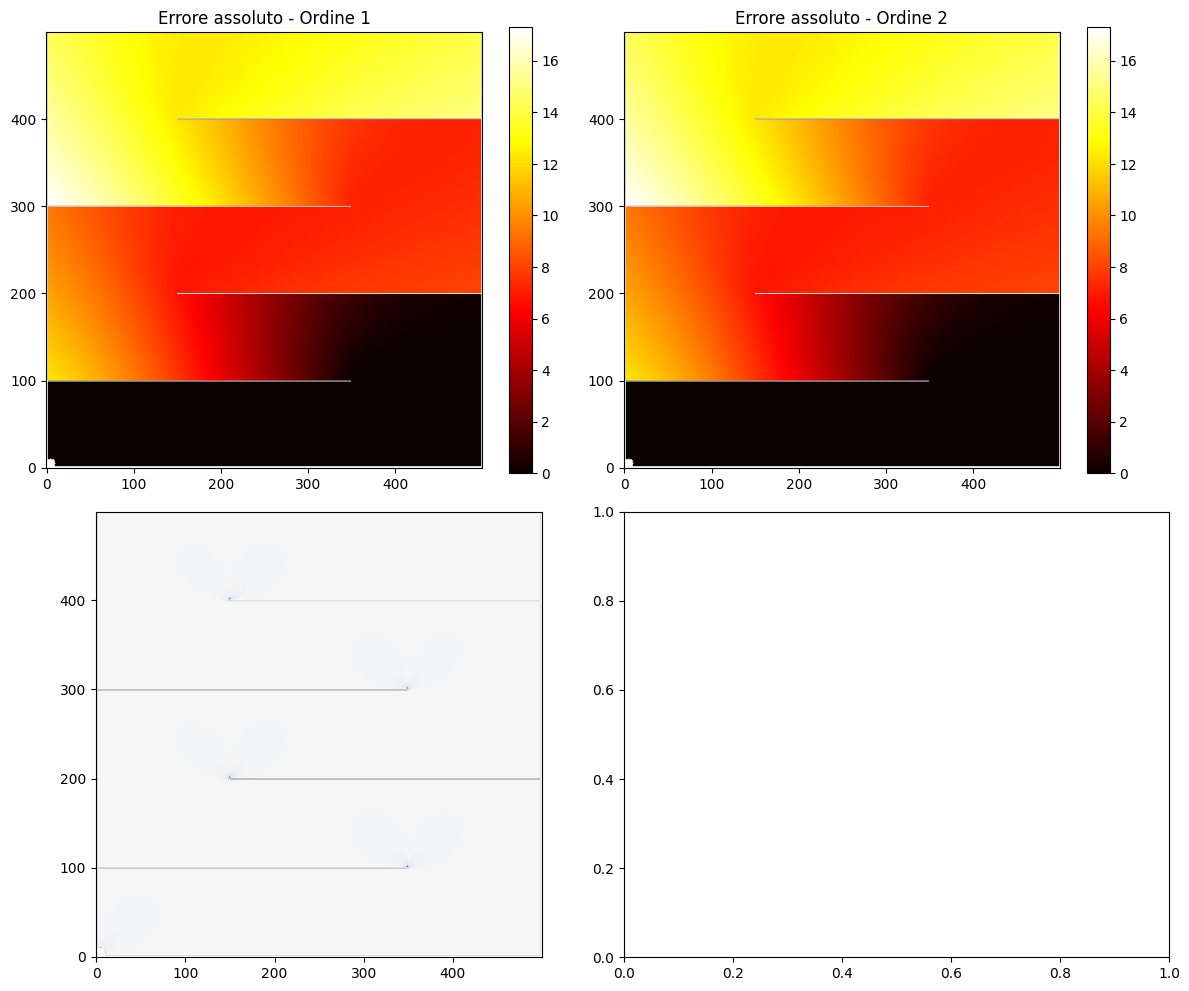

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# CONFRONTO ERRORE: T_order1 vs T_order2
# ==============================================================================

"""
def compare_errors(T_order1, T_order2, F, wall_mask, h, ix0, iy0,
                    exclude_radius=5, plot=True):
    nRows, nCols = T_order1.shape

    Y, X = np.meshgrid(np.arange(nRows), np.arange(nCols), indexing='ij')
    dist_from_source = np.sqrt((X - ix0)**2 + (Y - iy0)**2)
    exact = dist_from_source * h

    free_field = np.isclose(F, 1.0)
    reachable = np.isfinite(T_order1) & np.isfinite(T_order2)
    eval_zone = free_field & ~wall_mask & (dist_from_source > exclude_radius) & reachable

    n_unreachable = int((free_field & ~wall_mask & (dist_from_source > exclude_radius) & ~reachable).sum())
    if n_unreachable > 0:
      print(f"ATTENZIONE: {n_unreachable} punti nella zona libera risultano non raggiunti "
            f"(T=inf) e sono stati esclusi dal confronto. Controlla che il labirinto sia "
            f"completamente connesso rispetto alla sorgente.\n")
    if eval_zone.sum() == 0:
        raise ValueError("Nessun punto valutabile trovato: controlla F, wall_mask, exclude_radius")

    err1 = np.abs(T_order1 - exact)
    err2 = np.abs(T_order2 - exact)

    err1_eval = err1[eval_zone]
    err2_eval = err2[eval_zone]

    metrics = {
        'n_points_evaluated': int(eval_zone.sum()),
        'err_order1_max':  float(np.max(err1_eval)),
        'err_order2_max':  float(np.max(err2_eval)),
        'err_order1_mean': float(np.mean(err1_eval)),
        'err_order2_mean': float(np.mean(err2_eval)),
        'err_order1_L2':   float(np.sqrt(np.mean(err1_eval**2))),
        'err_order2_L2':   float(np.sqrt(np.mean(err2_eval**2))),
    }

    metrics['improvement_max_pct']  = 100 * (1 - metrics['err_order2_max']  / metrics['err_order1_max'])
    metrics['improvement_mean_pct'] = 100 * (1 - metrics['err_order2_mean'] / metrics['err_order1_mean'])
    metrics['improvement_L2_pct']   = 100 * (1 - metrics['err_order2_L2']   / metrics['err_order1_L2'])

    print("=" * 60)
    print("CONFRONTO ERRORE: ordine 1 vs ordine 2 (corretto)")
    print("=" * 60)
    print(f"Punti valutati (zona libera, fuori sorgente): {metrics['n_points_evaluated']}")
    print()
    print(f"{'Metrica':<20} {'Ordine 1':>12} {'Ordine 2':>12} {'Migliora %':>12}")
    print("-" * 60)
    print(f"{'Errore massimo':<20} {metrics['err_order1_max']:>12.6f} {metrics['err_order2_max']:>12.6f} {metrics['improvement_max_pct']:>11.1f}%")
    print(f"{'Errore medio':<20} {metrics['err_order1_mean']:>12.6f} {metrics['err_order2_mean']:>12.6f} {metrics['improvement_mean_pct']:>11.1f}%")
    print(f"{'Errore L2 (RMS)':<20} {metrics['err_order1_L2']:>12.6f} {metrics['err_order2_L2']:>12.6f} {metrics['improvement_L2_pct']:>11.1f}%")
    print("=" * 60)

    if metrics['improvement_mean_pct'] > 0:
        print(f"-> L'ordine 2 riduce l'errore medio del {metrics['improvement_mean_pct']:.1f}%")
    else:
        print(f"-> ATTENZIONE: l'ordine 2 e' PEGGIORE dell'ordine 1 in questo caso "
              f"({-metrics['improvement_mean_pct']:.1f}% peggio)")

    if plot:
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))

        err1_masked = np.where(eval_zone, err1, np.nan)
        err2_masked = np.where(eval_zone, err2, np.nan)
        vmax = np.nanmax([err1_masked, err2_masked])

        im0 = axes[0,0].imshow(err1_masked, origin='lower', vmin=0, vmax=vmax, cmap='hot')
        axes[0,0].set_title('Errore assoluto - Ordine 1')
        plt.colorbar(im0, ax=axes[0,0])

        im1 = axes[0,1].imshow(err2_masked, origin='lower', vmin=0, vmax=vmax, cmap='hot')
        axes[0,1].set_title('Errore assoluto - Ordine 2 (corretto)')
        plt.colorbar(im1, ax=axes[0,1])

        diff = err1_masked - err2_masked
        vmax_diff = np.nanmax(np.abs(diff))
        im2 = axes[1,0].imshow(diff, origin='lower', vmin=-vmax_diff, vmax=vmax_diff, cmap='RdBu')
        axes[1,0].set_title('Differenza (rosso = ordine2 migliore)')
        plt.colorbar(im2, ax=axes[1,0])

        axes[1,1].hist(err1_eval, bins=50, alpha=0.5, label='Ordine 1', density=True)
        axes[1,1].hist(err2_eval, bins=50, alpha=0.5, label='Ordine 2', density=True)
        axes[1,1].set_title('Distribuzione errori')
        axes[1,1].set_xlabel('Errore assoluto')
        axes[1,1].legend()

        plt.tight_layout()
        plt.show()

    return metrics
"""
def compare_errors(T_order1, T_order2, F, wall_mask, h, ix0, iy0,
                    exclude_radius=5, max_row_los=None, plot=True):
    """
    Confronta l'errore SOLO nella zona senza muri interposti tra sorgente e
    punto (line-of-sight valida), dove la distanza euclidea e' davvero la
    soluzione esatta. Oltre il primo muro il percorso reale passa per
    un'apertura, quindi la distanza euclidea non e' piu' un riferimento valido.
    """
    nRows, nCols = T_order1.shape

    Y, X = np.meshgrid(np.arange(nRows), np.arange(nCols), indexing='ij')
    dist_from_source = np.sqrt((X - ix0)**2 + (Y - iy0)**2)
    exact = dist_from_source * h

    if max_row_los is None:
        wall_rows = np.where(wall_mask.all(axis=1))[0]
        wall_rows_above = wall_rows[wall_rows > iy0]
        max_row_los = int(wall_rows_above.min()) if len(wall_rows_above) > 0 else nRows

    free_field = np.isclose(F, 1.0)
    reachable = np.isfinite(T_order1) & np.isfinite(T_order2)
    line_of_sight = (Y < max_row_los)

    eval_zone = free_field & ~wall_mask & (dist_from_source > exclude_radius) & reachable & line_of_sight

    n_unreachable = int((free_field & ~wall_mask & (dist_from_source > exclude_radius) & ~reachable).sum())
    if n_unreachable > 0:
        print(f"NOTA: {n_unreachable} punti non raggiunti esclusi dal confronto.")
    print(f"NOTA: valutazione ristretta a righe < {max_row_los} (line-of-sight libera dalla sorgente).\n")

    if eval_zone.sum() == 0:
        raise ValueError("Nessun punto valutabile trovato: controlla max_row_los")

    err1 = np.abs(T_order1 - exact)
    err2 = np.abs(T_order2 - exact)
    err1_eval = err1[eval_zone]
    err2_eval = err2[eval_zone]

    metrics = {
        'n_points_evaluated': int(eval_zone.sum()),
        'err_order1_max':  float(np.max(err1_eval)),
        'err_order2_max':  float(np.max(err2_eval)),
        'err_order1_mean': float(np.mean(err1_eval)),
        'err_order2_mean': float(np.mean(err2_eval)),
        'err_order1_L2':   float(np.sqrt(np.mean(err1_eval**2))),
        'err_order2_L2':   float(np.sqrt(np.mean(err2_eval**2))),
    }
    metrics['improvement_max_pct']  = 100 * (1 - metrics['err_order2_max']  / metrics['err_order1_max'])
    metrics['improvement_mean_pct'] = 100 * (1 - metrics['err_order2_mean'] / metrics['err_order1_mean'])
    metrics['improvement_L2_pct']   = 100 * (1 - metrics['err_order2_L2']   / metrics['err_order1_L2'])

    print("=" * 60)
    print("CONFRONTO ERRORE: ordine 1 vs ordine 2 (corretto)")
    print("=" * 60)
    print(f"Punti valutati: {metrics['n_points_evaluated']}")
    print(f"{'Metrica':<20} {'Ordine 1':>12} {'Ordine 2':>12} {'Migliora %':>12}")
    print("-" * 60)
    print(f"{'Errore massimo':<20} {metrics['err_order1_max']:>12.6f} {metrics['err_order2_max']:>12.6f} {metrics['improvement_max_pct']:>11.1f}%")
    print(f"{'Errore medio':<20} {metrics['err_order1_mean']:>12.6f} {metrics['err_order2_mean']:>12.6f} {metrics['improvement_mean_pct']:>11.1f}%")
    print(f"{'Errore L2 (RMS)':<20} {metrics['err_order1_L2']:>12.6f} {metrics['err_order2_L2']:>12.6f} {metrics['improvement_L2_pct']:>11.1f}%")
    print("=" * 60)

    if plot:
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        err1_masked = np.where(eval_zone, err1, np.nan)
        err2_masked = np.where(eval_zone, err2, np.nan)
        vmax = np.nanmax([err1_masked, err2_masked])
        im0 = axes[0,0].imshow(err1_masked, origin='lower', vmin=0, vmax=vmax, cmap='hot')
        axes[0,0].set_title('Errore assoluto - Ordine 1'); plt.colorbar(im0, ax=axes[0,0])
        im1 = axes[0,1].imshow(err2_masked, origin='lower', vmin=0, vmax=vmax, cmap='hot')
        axes[0,1].set_title('Errore assoluto - Ordine 2'); plt.colorbar(im1, ax=axes[0,1])
        diff = err1_masked - err2_masked
        vmax_diff = np.nanmax(np.abs(diff)) if np.isfinite(diff).any() else 1
        im2 = axes[1,0].imshow(diff, origin='lower', vmin=-vmax_diff, vmax=vmax_diff, cmap='RdBu')
        plt.tight_layout(); plt.show()

    return metrics
# ==============================================================================
# ESEMPIO DI CHIAMATA (adatta ai nomi delle tue variabili nel notebook)
# ==============================================================================
metrics = compare_errors(T_order1 = T_order1,T_order2 = T_order2,F=F,wall_mask=wall_mask,h=h,ix0=ix0,iy0=iy0,exclude_radius=5,plot=True)